In [1]:
#import libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
#load the dataset
df = pd.read_csv('ecommerce_bigdata.csv')

In [4]:
#remove unneccessary columns
df = df.drop(columns=["TransactionID"])

In [5]:
#convert date to month
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df = df.drop(columns=["Date"]) 

In [6]:
#Encode Categorical Columns
encoder = LabelEncoder()

for column in ["Region", "ProductCategory", "CustomerType"]:
    df[column] = encoder.fit_transform(df[column])

In [7]:
df.head()

,Region,ProductCategory,CustomerType,Sales,Profit,Month
0,1,2,2,4924,359.44,6
1,0,2,1,3283,944.32,2
2,2,3,0,4049,967.10,3
3,3,4,0,4331,434.57,6
4,3,4,1,3283,340.48,1


In [8]:
#defining features and target
X = df.drop("CustomerType", axis=1)
y = df["CustomerType"]

In [9]:
#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
#model 1: Logistic Regression
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.225
[[0 3 7]
 [2 2 6]
 [5 8 7]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.15      0.20      0.17        10
           2       0.35      0.35      0.35        20

    accuracy                           0.23        40
   macro avg       0.17      0.18      0.17        40
weighted avg       0.21      0.23      0.22        40



In [12]:
#model 2:Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.275
[[ 3  2  5]
 [ 4  2  4]
 [10  4  6]]
              precision    recall  f1-score   support

           0       0.18      0.30      0.22        10
           1       0.25      0.20      0.22        10
           2       0.40      0.30      0.34        20

    accuracy                           0.28        40
   macro avg       0.28      0.27      0.26        40
weighted avg       0.31      0.28      0.28        40



In [13]:
#model 3: Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.225
[[1 3 6]
 [6 1 3]
 [7 6 7]]
              precision    recall  f1-score   support

           0       0.07      0.10      0.08        10
           1       0.10      0.10      0.10        10
           2       0.44      0.35      0.39        20

    accuracy                           0.23        40
   macro avg       0.20      0.18      0.19        40
weighted avg       0.26      0.23      0.24        40



In [14]:
#comparing results:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression     0.225
1        Decision Tree     0.275
2        Random Forest     0.225


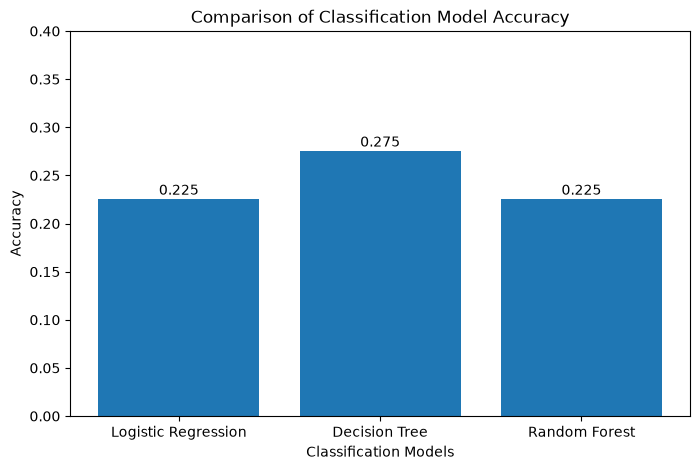

In [15]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [0.225, 0.275, 0.225]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Comparison of Classification Model Accuracy")
plt.xlabel("Classification Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.005, str(v), ha='center')

plt.ylim(0, 0.4)

plt.show()